## **Proj-00-Data Wrangling & Feature Engineering** 
### **Goal:** <br> Prepare the raw data to build a model that predicts if a trend will be Long-Lived (active for many hours/days) or Short-Lived (fades quickly).

In [2]:
## Importing Necessary Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect


#### **Loading and Eyeballing the Dataset**

In [3]:
## Loading the dataset
trends_data = pd.read_csv("trending_searches_in_us.csv")
trends_data.head()

,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown
0,nicolás maduro,2025-12-08 20:40:00+00:00,NaN,True,500,50,"Politics, Law and Government",NaN
1,man u,2025-12-08 20:20:00+00:00,NaN,True,1000,400,Sports,NaN
2,brooke rollins,2025-12-08 20:10:00+00:00,2025-12-08 20:50:00+00:00,False,500,50,"Politics, Law and Government",NaN
3,jermaine burton,2025-12-08 20:00:00+00:00,NaN,True,10000,1000,Sports,bengals game today
4,tolima - fortaleza,2025-12-08 20:00:00+00:00,NaN,True,500,100,Sports,NaN


In [4]:
print(trends_data.info())
print(f"\n{trends_data.shape}")
trends_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43374 entries, 0 to 43373
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   query                43374 non-null  object
 1   start_date           43374 non-null  object
 2   end_date             38762 non-null  object
 3   active               43374 non-null  bool  
 4   search_volume        43374 non-null  int64 
 5   increase_percentage  43374 non-null  int64 
 6   categories           43374 non-null  object
 7   trend_breakdown      16360 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 2.4+ MB
None

(43374, 8)


,search_volume,increase_percentage
count,4.337400e+04,43374.000000
mean,2.202830e+04,221.530756
std,1.646482e+05,261.377209
min,1.000000e+02,50.000000
25%,5.000000e+02,75.000000
50%,2.000000e+03,100.000000
75%,5.000000e+03,200.000000
max,1.000000e+07,1000.000000


In [5]:
## Checking for missing values
print(trends_data.columns.tolist())
print(trends_data.isnull().sum())

['query', 'start_date', 'end_date', 'active', 'search_volume', 'increase_percentage', 'categories', 'trend_breakdown']
query                      0
start_date                 0
end_date                4612
active                     0
search_volume              0
increase_percentage        0
categories                 0
trend_breakdown        27014
dtype: int64


#### **Query**

In [6]:
## Checking if all values are unique
print(f"Total Number of unique values: {trends_data['query'].nunique()}")
print(f"Total number of values: {len(trends_data['query'])}")

## Normalizing text
trends_data['query'] = trends_data['query'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
trends_data['query']

Total Number of unique values: 24610
Total number of values: 43374


0                   nicolás maduro
1                            man u
2                   brooke rollins
3                  jermaine burton
4               tolima - fortaleza
                   ...            
43369    sydney mclaughlin-levrone
43370                  eugene levy
43371                 constance wu
43372               bills dolphins
43373                  marco rubio
Name: query, Length: 43374, dtype: object

In [7]:
## Creating a function to detect and classify differet query languages 

from langdetect import detect, LangDetectException

def safeDetect(text):
    """Safely detects language, returning 'unknown' if no features are found."""
    try:
        if not isinstance(text, str):
            return 'unknown'
        return detect(text)
    
    except LangDetectException:
        return 'unknown'
    

In [ ]:
trends_data['query_language'] = trends_data['query'].apply(safeDetect)
trends_data.head(10)

#### **start_date**

In [ ]:
## Checking data types
print(type(trends_data.start_date[0]))

## Converting data to datatime
trends_data['start_date'] = pd.to_datetime(trends_data['start_date'], errors = 'coerce')
trends_data.head()

<class 'str'>


,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown,query_language
0,nicolás maduro,2025-12-08 20:40:00+00:00,NaN,True,500,50,"Politics, Law and Government",NaN,es
1,man u,2025-12-08 20:20:00+00:00,NaN,True,1000,400,Sports,NaN,tl
2,brooke rollins,2025-12-08 20:10:00+00:00,2025-12-08 20:50:00+00:00,False,500,50,"Politics, Law and Government",NaN,af
3,jermaine burton,2025-12-08 20:00:00+00:00,NaN,True,10000,1000,Sports,bengals game today,fr
4,tolima - fortaleza,2025-12-08 20:00:00+00:00,NaN,True,500,100,Sports,NaN,it


In [ ]:
## Checking if any row fail to convert
not_time_values = trends_data['start_date'].isna().sum()
print(f"Rows with invalid/missing start_date:{not_time_values}\n")

## Checking for number of rows with duplicate timestamps
nduplicates = trends_data['start_date'].duplicated(keep = False).sum()
print(f"Number of Rows with duplicate 'start_date': {nduplicates}\n")

duplicates_df = trends_data[trends_data['start_date'].duplicated(keep = False)]
print("Sample of duplicate 'start_date':")
duplicates_df[['query', 'start_date']].head(10)

Rows with invalid/missing start_date:0

Number of Rows with duplicate 'start_date': 41467

Sample of duplicate 'start_date':


,query,start_date
3,jermaine burton,2025-12-08 20:00:00+00:00
4,tolima - fortaleza,2025-12-08 20:00:00+00:00
5,brett rypien,2025-12-08 20:00:00+00:00
6,pete alonso,2025-12-08 20:00:00+00:00
7,daison acosta,2025-12-08 19:50:00+00:00
8,gavin newsom,2025-12-08 19:50:00+00:00
9,omarion hampton,2025-12-08 19:40:00+00:00
10,corey lewandowski,2025-12-08 19:40:00+00:00
12,cruise ship,2025-12-08 19:20:00+00:00
13,alina habba,2025-12-08 19:20:00+00:00


In [ ]:
## Checking earliest and latest trends 'start_dates'
print(f"Earliest Trends 'start_date': {trends_data.start_date.min()}\n")
print(f"Latest Trends 'start_date': {trends_data.start_date.max()}\n")

today = pd.Timestamp.now(tz = 'UTC')
future_dates = trends_data[trends_data['start_date'] > today]
print(f"Rows with future dates:{len(future_dates)}")

Earliest Trends 'start_date': 2025-09-18 12:50:00+00:00

Latest Trends 'start_date': 2025-12-08 20:40:00+00:00

Rows with future dates:0


In [ ]:
## Extracting start-hour and start_day features 
trends_data['start_hour'] = trends_data.start_date.dt.hour
trends_data['start_day'] = trends_data.start_date.dt.day_of_week

trends_data.head()

,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown,query_language,start_hour,start_day
0,nicolás maduro,2025-12-08 20:40:00+00:00,NaN,True,500,50,"Politics, Law and Government",NaN,es,20,0
1,man u,2025-12-08 20:20:00+00:00,NaN,True,1000,400,Sports,NaN,tl,20,0
2,brooke rollins,2025-12-08 20:10:00+00:00,2025-12-08 20:50:00+00:00,False,500,50,"Politics, Law and Government",NaN,af,20,0
3,jermaine burton,2025-12-08 20:00:00+00:00,NaN,True,10000,1000,Sports,bengals game today,fr,20,0
4,tolima - fortaleza,2025-12-08 20:00:00+00:00,NaN,True,500,100,Sports,NaN,it,20,0


#### **end_date**

In [ ]:
## Checking the data type
print(type(trends_data.end_date[0]))

## Converting 'end_date' to timestamp
trends_data['end_date'] = pd.to_datetime(trends_data.end_date, errors = 'coerce')
print(type(trends_data.end_date[0]))

<class 'float'>
<class 'pandas._libs.tslibs.nattype.NaTType'>


In [ ]:
## Active trends should have missing end_date because they have not ended
active_missing_end_date = trends_data[trends_data.active == True].end_date.isna().sum()
active_total = (trends_data.active == True).sum()
active_percentage = (active_missing_end_date/active_total) * 100

## end_date for inactive trends should not be missing
inactive_missing_end_date = trends_data[trends_data.active == False].end_date.isna().sum()
inactive_total = (trends_data.active == False).sum()
inactive_percentage = (inactive_missing_end_date/inactive_total)* 100


## Creating a summary table for active and inactive trends with missing end_date
end_date_missing_summary = pd.DataFrame({
                                         'Trend_Status': ['Active', 'Inactive', 'TT'],
                                         'Missing_end_date': [active_missing_end_date, inactive_missing_end_date, 
                                                              (active_missing_end_date + inactive_missing_end_date)],
                                         'Total': [active_total, inactive_total, (active_total + inactive_total)],
                                         'Percentage_missing': [active_percentage, inactive_percentage, 
                                                                (active_percentage + inactive_percentage)]
                                        })
print(end_date_missing_summary, '\n')

## Checking end_date data integrity
if end_date_missing_summary.Percentage_missing[0] == 100.0 and end_date_missing_summary.Percentage_missing[1] == 0.0:
    print("✅'end_date' is consistent with active trends status.")
else:
    print("⚠️'end_date' is not consistent with active trends status")

  Trend_Status  Missing_end_date  Total  Percentage_missing
0       Active              4612   4612               100.0
1     Inactive                 0  38762                 0.0
2           TT              4612  43374               100.0 

✅'end_date' is consistent with active trends status.


In [ ]:
## Checking date logic errors: 'start_date is greater than end_date'
start_date_end_date = trends_data[~trends_data['start_date'].isna() & ~trends_data['end_date'].isna()]

date_error = start_date_end_date[start_date_end_date['end_date'] < start_date_end_date['start_date']]
for date in date_error:
    if date == True:
        print(f"⚠️{date} date logic error: trend's end_date is before start_date")
    else:
        print(f"✅ Date logic is valid.")

## Checking date logic error: 'end_date is in the future'
today = pd.Timestamp.now(tz='UTC')
future_trends = trends_data[trends_data['end_date'] > today]

if not future_trends.empty:
    print(f"\n⚠️ end_date logic error: {len(future_trends)} rows show trend ending in the future.")
else:
    print(f"\n✅ Date logic is valid: All end_dates are within time.")


✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.
✅ Date logic is valid.

✅ Date logic is valid: All end_dates are within time.


In [ ]:
## Finding the latest time in the dataset
latest_start_date = trends_data['start_date'].max()
latest_end_date = trends_data['end_date'].max()
reference_timestamp = max(latest_start_date, latest_end_date)

## Calculating the trend duration for active rows and inactive rows
trends_data['trend_duration'] = np.where(
                                         trends_data['end_date'].isna(),
                                         reference_timestamp - trends_data['start_date'],
                                         trends_data['end_date'] - trends_data['start_date']
                                         )

## Converting "trend_duration" to hours in the "duration_hours" column
trends_data['duration_hours'] = trends_data['trend_duration'].dt.total_seconds()/3600

## Since some durations are still active, we don't really know their actual trend_duration
## Creating a flag("duration_type"), minimun for trend_durations of active trends and actual for in active trends
trends_data['duration_type'] = np.where(trends_data['active'] == True, 'minimum', 'actual')


## Rearranging the the columns in a more logical order
trends_data = trends_data[
                            ['query', 'query_language', 'start_date', 'end_date', 'active', 'trend_duration', 
                             'duration_hours', 'duration_type', 'start_hour', 'start_day', 'search_volume',
                             'increase_percentage', 'categories', 'trend_breakdown']
                        ]

trends_data.head()

,query,query_language,start_date,end_date,active,trend_duration,duration_hours,duration_type,start_hour,start_day,search_volume,increase_percentage,categories,trend_breakdown
0,nicolás maduro,es,2025-12-08 20:40:00+00:00,NaT,True,0 days 00:10:00,0.166667,minimum,20,0,500,50,"Politics, Law and Government",NaN
1,man u,tl,2025-12-08 20:20:00+00:00,NaT,True,0 days 00:30:00,0.500000,minimum,20,0,1000,400,Sports,NaN
2,brooke rollins,af,2025-12-08 20:10:00+00:00,2025-12-08 20:50:00+00:00,False,0 days 00:40:00,0.666667,actual,20,0,500,50,"Politics, Law and Government",NaN
3,jermaine burton,fr,2025-12-08 20:00:00+00:00,NaT,True,0 days 00:50:00,0.833333,minimum,20,0,10000,1000,Sports,bengals game today
4,tolima - fortaleza,it,2025-12-08 20:00:00+00:00,NaT,True,0 days 00:50:00,0.833333,minimum,20,0,500,100,Sports,NaN


In [ ]:
## Total Trends Durations
tt_trend_hrs = trends_data['duration_hours'].sum()
tt_trend_days = tt_trend_hrs/24

print(f"Total Trend Hours for Active and Inactive Trends: {tt_trend_hrs:.2f}")
print(f"Total Trend Duration in Days: {tt_trend_days:.0f}\n")
## Data for Inactive trends (Trends that have ended)
inactive_trend_durations = trends_data.loc[trends_data.active == False, 'duration_hours']
in_count = len(inactive_trend_durations)
in_longest = round(inactive_trend_durations.max(), 2)
in_shortest = round(inactive_trend_durations.min(), 2)
in_median = round(inactive_trend_durations.median(), 2)
in_mean = round(inactive_trend_durations.mean(), 2)
in_7th = inactive_trend_durations.quantile(0.75)

## Data for Active trends (Trends that have not ended)
active_trend_durations = trends_data.loc[trends_data.active == True, 'duration_hours']
act_count = len(active_trend_durations)
act_longest = round(active_trend_durations.max(), 2)
act_shortest = round(active_trend_durations.min(), 2)
act_median = round(active_trend_durations.median(), 2)
act_mean = round(active_trend_durations.mean(), 2)
act_75th = active_trend_durations.quantile(0.75)

trend_summary_df = pd.DataFrame({'Trend_Status':['Active', 'Ended'],
                                 'Trend_Count': [act_count, in_count],
                                 'Longest_trend(hrs)': [act_longest, in_longest],
                                 'Shortest_trend(hrs)':[act_shortest, in_shortest],
                                 'Median_Trend(hrs)': [act_median, in_median],
                                 'Mean_Trend(hrs)': [act_mean, in_mean],
                                 'longest_Trend_hrs_Per(%)': [round((act_longest/tt_trend_hrs)*100, 3),
                                                           round((in_longest/tt_trend_hrs)*100, 3)]
                                })
trend_summary_df

Total Trend Hours for Active and Inactive Trends: 6147021.50
Total Trend Duration in Days: 256126



,Trend_Status,Trend_Count,Longest_trend(hrs),Shortest_trend(hrs),Median_Trend(hrs),Mean_Trend(hrs),longest_Trend_hrs_Per(%)
0,Active,4612,1952.00,0.17,1413.92,1266.64,0.032
1,Ended,38762,162.67,0.33,3.00,7.88,0.003


In [ ]:
## Calculaing duration treshold
duration_below_24hrs = (trends_data['duration_hours'] < 24.0).sum()
duration_above_24hrs = (trends_data['duration_hours'] >= 24.0).sum()
duration_24hrs = (trends_data['duration_hours'] == 24.0).sum()
print(f"Trends that lasted 24hrs: {duration_24hrs}\nTrends Above 24hrs: {duration_above_24hrs}\nTrends Below 24hrs: {duration_below_24hrs}")

Trends that lasted 24hrs: 27
Trends Above 24hrs: 7442
Trends Below 24hrs: 35932


In [ ]:
## Percentages for Active and Inactive Trends
active_percentage = round((len(trends_data.loc[trends_data.active == True])) / (len(trends_data)) * 100, 2)
inactive_percentage = round((len(trends_data.loc[trends_data.active == False]))/ len(trends_data) * 100 ,2)

## Calculating Inactive trends treshold
inactive_below_24hrs = (trends_data.loc[trends_data.active == False, 'duration_hours'] < 24.0).sum()
      ### Trend lasted 24 hours and above
inactive_24hrs_above = (trends_data.loc[trends_data.active == False, 'duration_hours'] >= 24.0).sum()

## Calculating Active Treshold
active_below_24hrs = (trends_data.loc[trends_data.active == True, 'duration_hours'] < 24.0).sum()
      ### Trend lasted 24 hours and above
active_24hrs_above = (trends_data.loc[trends_data.active == True, 'duration_hours'] >= 24.0).sum()

### **Business Problem:**<br>Can a rising Google search query remain relevantly long enough to justify a full marketing campaign?



In [ ]:
# Initialize the column with NaN (unknown)
trends_data['long_lived'] = np.nan

# Assign labels ONLY to inactive (ended) trends
trends_data.loc[trends_data.active == False, 'long_lived'] = (
    trends_data.loc[trends_data.active == False, 'duration_hours'] >= 24.0
).astype(int)

# Validate labels
print(trends_data['long_lived'].value_counts(dropna=False))


long_lived
0.0    35885
NaN     4612
1.0     2877
Name: count, dtype: int64


#### **Training Dataset**

In [ ]:
## Creating training dataset from rows with ended trends (label is known)
training_df = trends_data.loc[trends_data['long_lived'].notna()].copy()
## Keeping active trends for future prediction
active_trends = trends_data.loc[trends_data.long_lived.isna()].copy()

print(f"Training dataset:{training_df.shape}\n")
## Validate long_lived labels in training dataset
print(training_df.long_lived.value_counts()) 

Training dataset:(38762, 15)

long_lived
0.0    35885
1.0     2877
Name: count, dtype: int64


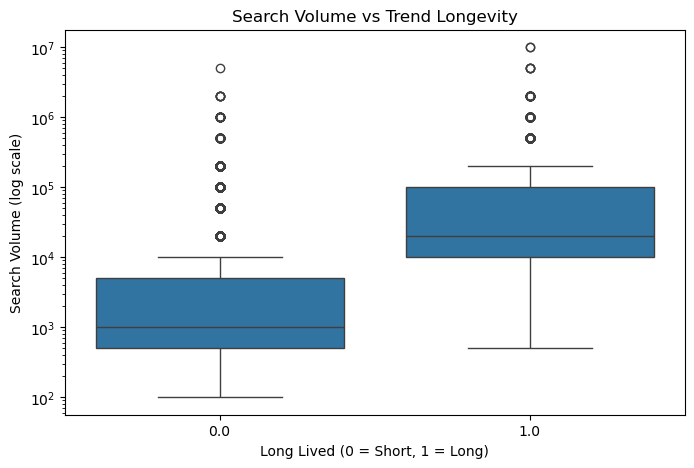

In [ ]:
## Comparing search volumes for short vs long_lived
training_df.groupby('long_lived').search_volume.describe()

plt.figure(figsize = (8,5))
sns.boxplot(
    data = training_df,
    x = 'long_lived',
    y = 'search_volume')

plt.yscale('log')  # search volume is very skewed
plt.xlabel('Long Lived (0 = Short, 1 = Long)')
plt.ylabel('Search Volume (log scale)')
plt.title('Search Volume vs Trend Longevity')
plt.show()

#### Short-lived trends generally show modest growth, while long-lived trends tend to grow faster and display a wider range of growth speeds, suggesting that rapid early growth is an important—but not sufficient—signal of trend longevity.

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=training_df,
    x='long_lived',
    y='increase_percentage'
)

plt.xlabel('Long Lived (0 = Short, 1 = Long)')
plt.ylabel('Increase Percentage')
plt.title('Search Growth vs Trend Longevity')
plt.show()


# Compare increase percentage for short vs long-lived trends
training_df.groupby('long_lived')['increase_percentage'].describe()

NameError: name 'plt' is not defined